<a href="https://colab.research.google.com/github/imjesusgarcia/Project-ConnectaTel-Student/blob/main/S8_Student_Version_Project_NovaRetail_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [ ]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

### Cargar Dataset

In [ ]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [ ]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
-

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna ... .


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [ ]:
# Corregir el tipo de dato
df['edad'] = df['edad'].astype(int)

In [ ]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [ ]:
# Estadísticas descriptivas de variables numéricas
df.describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables numéricas

- **edad** — rango 18-75, media y mediana casi iguales (38.26 / 38), distribución simétrica sin outliers evidentes.
- **nivel_ingreso** — rango 8,000-74,790, media ≈ mediana (~30,000), dispersión amplia (std 9,833) pero sin asimetría marcada.
- **visitas_mes** — rango 1-25, media y mediana coinciden en 10, distribución bastante simétrica.
- **compras_mes** — rango 0-8, media 1.21 pero mediana 1 y P75 apenas 2: asimetría positiva, mayoría de clientes compra poco o nada al mes.
- **gasto_publicidad_dirigida** — rango 0-75.51, media (20.15) y mediana (19.73) cercanas; el mínimo en 0 indica clientes sin inversión publicitaria dirigida.
- **satisfaccion** — escala tipo Likert (1-5), media 3.6, distribución centrada hacia valores medio-altos.
- **miembro_premium** — binaria, media 0.139 → solo ~14% de los clientes son premium, clase desbalanceada.
- **abandono** — binaria, media 0.151 → ~15% tasa de abandono (churn), también desbalanceada.
- **ingreso_anual** — rango 0-244.69, media (36.59) muy por encima de la mediana (30.70): asimetría positiva, posible cola de clientes de alto valor; el mínimo en 0 amerita revisión (¿clientes inactivos o sin compras registradas?).

#### Explorar variables binarias

In [ ]:
# Verificar que cada columna tenga únicamente dos valores posibles
print(df['miembro_premium'].unique())
print(df['abandono'].unique())

[0 1]
[0 1]


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables binarias

- **miembro_premium** — solo dos valores (0 y 1), correctamente codificada. ~14% de los clientes son premium, clase minoritaria.
- **abandono** — solo dos valores (0 y 1), correctamente codificada. ~15% de los clientes presentan abandono (churn), clase minoritaria.

#### Explorar variables categóricas

In [ ]:
# Verificar el número de valores únicos por variable categórica
print(df['tipo_dispositivo'].nunique())
print(df['region'].nunique())

3
4


In [ ]:
# Explorar variables categóricas y cómo se distribuyen
print(df['tipo_dispositivo'].value_counts())
print()
print(df['region'].value_counts())

móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64

norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables categóricas

- **tipo_dispositivo** — 3 categorías. Predomina móvil (9,818, ~65%), seguido de escritorio (3,720, ~25%) y tablet (1,462, ~10%); distribución desbalanceada hacia móvil.
- **region** — 4 categorías. Distribución relativamente equilibrada: norte (4,395), oeste (3,810), sur (3,726), este (3,069), sin una región dominante marcada.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

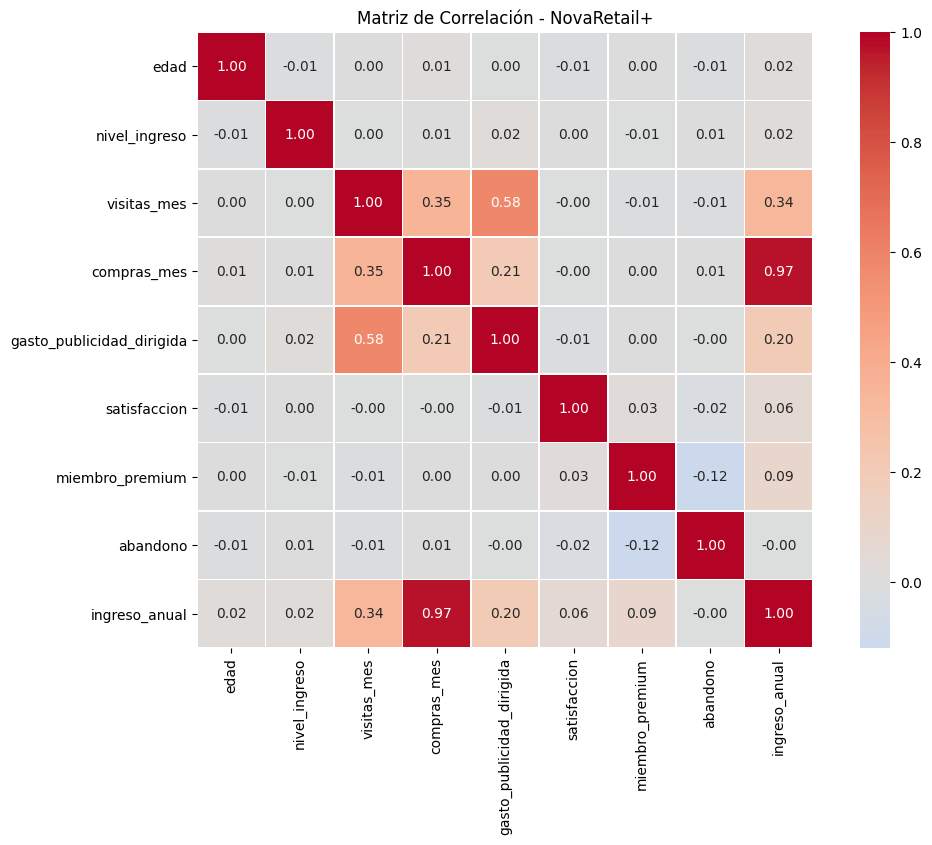

In [ ]:
# Visualizar la matriz de correlación para identificar relaciones
corr_matrix = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Matriz de Correlación - NovaRetail+')
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves


Observaciones generales (Heatmap)

- Se observa que la mayoría de las variables numéricas presentan correlaciones débiles entre sí (|r| < 0.2), salvo algunas excepciones puntuales.
- `visitas_mes` y `gasto_publicidad_dirigida` muestran una correlación moderada (0.58).
- `visitas_mes` y `compras_mes` tienen una correlación débil-moderada (0.35).
- `miembro_premium` y `abandono` presentan una correlación negativa débil (-0.12).
- `edad` y `nivel_ingreso` no muestran relación lineal relevante con ninguna otra variable (|r| ≤ 0.02).

Observaciones respecto a `ingreso_anual`

- Presenta una correlación extremadamente fuerte con `compras_mes` (0.97), muy por encima del resto de relaciones del dataset. Esta magnitud es atípica y amerita validación adicional antes de tratarla como hallazgo de negocio (posible redundancia entre variables, no necesariamente un patrón de comportamiento).
- Mantiene una correlación débil-moderada con `visitas_mes` (0.34) y débil con `gasto_publicidad_dirigida` (0.20).
- Con `miembro_premium` (0.09), `satisfaccion` (0.06), `edad` (0.02) y `nivel_ingreso` (0.02) la correlación es prácticamente nula.
- Con `abandono` (-0.00) no existe relación lineal observable.

### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.

- **Si decides no incluirlo**:
  - Explica por qué.

### Scatterplot para pares clave

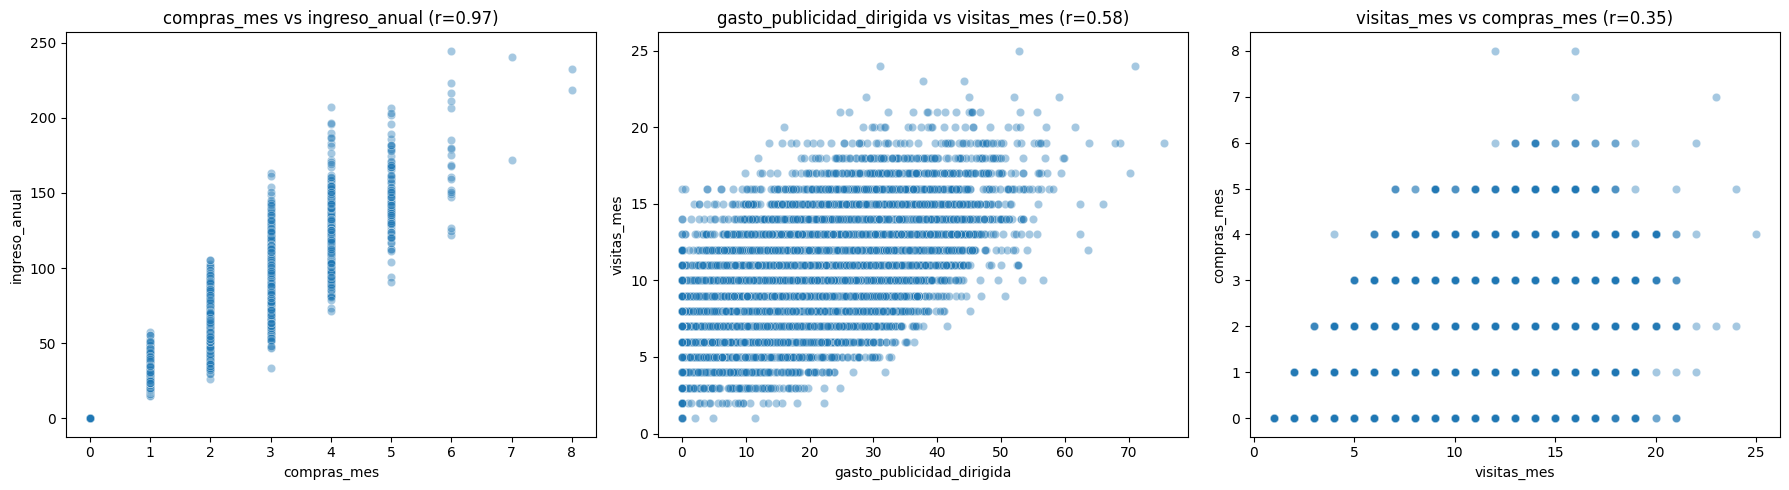

In [ ]:
# Visualizar pares de variables con relaciones moderadas o fuertes
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df, x='compras_mes', y='ingreso_anual', ax=axes[0], alpha=0.4)
axes[0].set_title('compras_mes vs ingreso_anual (r=0.97)')

sns.scatterplot(data=df, x='gasto_publicidad_dirigida', y='visitas_mes', ax=axes[1], alpha=0.4)
axes[1].set_title('gasto_publicidad_dirigida vs visitas_mes (r=0.58)')

sns.scatterplot(data=df, x='visitas_mes', y='compras_mes', ax=axes[2], alpha=0.4)
axes[2].set_title('visitas_mes vs compras_mes (r=0.35)')

plt.tight_layout()
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), dispersión (alta, media, baja), presencia de outliers y posible colinealidad.


Observaciones iniciales (Scatterplot)

**compras_mes vs ingreso_anual**

- Dirección: positiva, relación visualmente lineal y muy marcada.
- Dispersión: baja, los puntos se agrupan de forma ajustada en bandas estrechas por cada valor de compras_mes.
- Outliers: un punto en (0, 0) se separa del resto del patrón.
- Colinealidad: la magnitud (r=0.97) y el patrón visual sugieren que ambas variables podrían estar midiendo información redundante o derivada una de la otra; se recomienda validar su definición antes de usarlas juntas en modelos.

**gasto_publicidad_dirigida vs visitas_mes**

- Dirección: positiva.
- Dispersión: media-alta, los puntos forman una nube amplia sin un patrón lineal estrecho.
- Outliers: no se observan puntos claramente separados del resto.
- Colinealidad: no hay indicios de redundancia entre las variables.

**visitas_mes vs compras_mes**

- Dirección: positiva, débil.
- Dispersión: alta, los puntos se distribuyen en una nube amplia con mucho solapamiento.
- Outliers: no se observan puntos claramente separados del resto.
- Colinealidad: no hay indicios de redundancia entre las variables.

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [ ]:
# Calcular correlación entre variables relevantes
pearson_compras = df['compras_mes'].corr(df['ingreso_anual'], method='pearson')
pearson_visitas_pub = df['gasto_publicidad_dirigida'].corr(df['visitas_mes'], method='pearson')
pearson_visitas_compras = df['visitas_mes'].corr(df['compras_mes'], method='pearson')

print(f"Pearson compras_mes vs ingreso_anual: {pearson_compras:.3f}")
print(f"Pearson gasto_publicidad_dirigida vs visitas_mes: {pearson_visitas_pub:.3f}")
print(f"Pearson visitas_mes vs compras_mes: {pearson_visitas_compras:.3f}")

Pearson compras_mes vs ingreso_anual: 0.967
Pearson gasto_publicidad_dirigida vs visitas_mes: 0.579
Pearson visitas_mes vs compras_mes: 0.354


In [ ]:
# Calcular correlación entre variables relevantes
# Calcular correlación entre variables relevantes
spearman_compras = df['compras_mes'].corr(df['ingreso_anual'], method='spearman')
spearman_visitas_pub = df['gasto_publicidad_dirigida'].corr(df['visitas_mes'], method='spearman')
spearman_visitas_compras = df['visitas_mes'].corr(df['compras_mes'], method='spearman')

print(f"Spearman compras_mes vs ingreso_anual: {spearman_compras:.3f}")
print(f"Spearman gasto_publicidad_dirigida vs visitas_mes: {spearman_visitas_pub:.3f}")
print(f"Spearman visitas_mes vs compras_mes: {spearman_visitas_compras:.3f}")

Spearman compras_mes vs ingreso_anual: 0.967
Spearman gasto_publicidad_dirigida vs visitas_mes: 0.559
Spearman visitas_mes vs compras_mes: 0.333


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves: dirección, magnitud y posible colinealidad.


Observaciones de correlación

**compras_mes vs ingreso_anual**

- Correlación: muy fuerte y positiva (Pearson 0.967, Spearman 0.967).
- La coincidencia casi exacta entre Pearson y Spearman confirma que la relación es lineal, no solo monotónica. La magnitud extrema sugiere posible colinealidad o redundancia entre ambas variables; se recomienda validar su origen/definición antes de usarlas juntas como predictores independientes.

**gasto_publicidad_dirigida vs visitas_mes**

- Correlación: moderada y positiva (Pearson 0.579, Spearman 0.559).
- Pearson y Spearman son similares, indicando una relación moderadamente lineal sin distorsión fuerte por outliers. No hay indicios de colinealidad problemática.

**visitas_mes vs compras_mes**

- Correlación: débil-moderada y positiva (Pearson 0.354, Spearman 0.333).
- Pearson y Spearman son cercanos, consistente con la nube dispersa observada en el scatterplot. No hay indicios de colinealidad.

### Punto-biserial

In [ ]:
# Calcular correlación entre variables relevantes
r_premium, p_premium = stats.pointbiserialr(df['miembro_premium'], df['ingreso_anual'])
r_abandono, p_abandono = stats.pointbiserialr(df['abandono'], df['ingreso_anual'])

print(f"Punto-biserial miembro_premium vs ingreso_anual: r={r_premium:.3f}, p={p_premium:.4f}")
print(f"Punto-biserial abandono vs ingreso_anual: r={r_abandono:.3f}, p={p_abandono:.4f}")

Punto-biserial miembro_premium vs ingreso_anual: r=0.093, p=0.0000
Punto-biserial abandono vs ingreso_anual: r=-0.003, p=0.7295


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), magnitud (alta, media, baja).

Observaciones Punto-biserial

**miembro_premium vs ingreso_anual**

- Relación: positiva, magnitud baja (r=0.093). Estadísticamente significativa (p<0.0001) dado el tamaño de muestra, pero la magnitud práctica es muy pequeña: ser miembro premium explica muy poco de la variación en ingreso_anual.

**abandono vs ingreso_anual**

- Relación: prácticamente nula (r=-0.003) y no significativa (p=0.7295). No hay evidencia de asociación lineal entre el abandono y el ingreso anual.

### V de Cramér

In [ ]:
# Función para calcular V de Cramér
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k - 1, r - 1))

In [ ]:
# Aplicar V de Cramér en variables relevantes
v_dispositivo_region = cramers_v(df['tipo_dispositivo'], df['region'])
v_dispositivo_abandono = cramers_v(df['tipo_dispositivo'], df['abandono'])
v_region_abandono = cramers_v(df['region'], df['abandono'])

print(f"V de Cramér tipo_dispositivo vs region: {v_dispositivo_region:.3f}")
print(f"V de Cramér tipo_dispositivo vs abandono: {v_dispositivo_abandono:.3f}")
print(f"V de Cramér region vs abandono: {v_region_abandono:.3f}")

V de Cramér tipo_dispositivo vs region: 0.012
V de Cramér tipo_dispositivo vs abandono: 0.007
V de Cramér region vs abandono: 0.015


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.
Incluye qué ves

Observaciones V de Cramér

Las tres asociaciones evaluadas son prácticamente nulas (V < 0.02 en todos los casos), muy por debajo del umbral de asociación débil (~0.1). Esto indica que `tipo_dispositivo` y `region` son independientes entre sí, y que ninguna de las dos variables categóricas tiene relación relevante con el `abandono` de clientes.

## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---

✍️ **Hallazgos**: Completa los siguientes bloques.   
Si lo crees necesario, puedes agregar mas hallazgos.  

Recuerda eliminar este bloque de texto antes de incluir el proyecto en tu portafolio.

### Hallazgo 1 —

Hallazgo 1 — Relación extremadamente fuerte entre compras_mes e ingreso_anual

**Evidencia visual:** El scatterplot muestra una tendencia lineal muy marcada y poco dispersa entre `compras_mes` e `ingreso_anual`.

**Evidencia numérica:** Correlación de Pearson 0.967 y Spearman 0.967, prácticamente idénticas, lo que confirma una relación lineal (no solo monotónica).

**Interpretación:** El número de compras mensuales es la variable de comportamiento más fuertemente asociada al ingreso anual generado por el cliente. Dado que ambos coeficientes coinciden casi exactamente, la magnitud es atípicamente alta para variables de comportamiento independientes, lo que sugiere posible colinealidad o que `ingreso_anual` podría derivarse parcialmente de `compras_mes` (relación de cálculo, no solo de comportamiento).

**No podemos afirmar:** Que comprar más mensualmente *cause* un mayor ingreso anual, ni que incentivar artificialmente las compras mensuales generará un aumento proporcional en el ingreso. Tampoco podemos descartar que ambas variables compartan una fuente de cálculo común.

**Implicación de negocio:** Antes de usar `compras_mes` como palanca de crecimiento o como predictor en modelos, se recomienda validar con el equipo de datos si existe dependencia estructural entre ambas variables. Si se confirma que son independientes, `compras_mes` sería el indicador de comportamiento más relevante para monitorear y segmentar clientes de alto valor.


### Hallazgo 2 —

Hallazgo 2 — Relación moderada entre gasto_publicidad_dirigida y visitas_mes

**Evidencia visual:** El scatterplot muestra una nube de puntos con tendencia positiva, pero con dispersión media-alta (no tan ajustada como en el Hallazgo 1).

**Evidencia numérica:** Correlación de Pearson 0.579 y Spearman 0.559, valores cercanos entre sí, consistentes con una relación moderadamente lineal sin distorsión fuerte por outliers.

**Interpretación:** Los clientes expuestos a mayor gasto en publicidad dirigida tienden a visitar la plataforma con mayor frecuencia. Es una asociación real pero parcial: la publicidad dirigida no explica por sí sola el comportamiento de visitas (R² ≈ 0.34, deja gran parte de la variación sin explicar).

**No podemos afirmar:** Que aumentar el gasto en publicidad dirigida *cause* un incremento en las visitas. La relación podría estar influida por factores no medidos (ej. clientes ya más activos reciben más publicidad dirigida por targeting algorítmico), o ir en sentido inverso.

**Implicación de negocio:** La publicidad dirigida es candidata a una prueba controlada (A/B test) para confirmar si existe un efecto causal real antes de aumentar la inversión. Como hallazgo correlacional, sugiere que el segmento de clientes con mayor gasto publicitario dirigido es también el más activo en visitas, útil para priorizar a quién dirigir nuevas campañas.


## Sección 6 - Limitaciones y próximos pasos

✍️ **Comentario**: Completa el siguiente bloque.   
Modifica según creas necesario.  

Recuerda eliminar este bloque de texto antes de incluir el proyecto en tu portafolio.

### **Limitaciones**
- Correlación ≠ causalidad: las relaciones identificadas (compras_mes-ingreso_anual, gasto_publicidad_dirigida-visitas_mes) son asociativas, no permiten afirmar que una variable cause cambios en otra.
- Posible colinealidad no resuelta entre `compras_mes` e `ingreso_anual`: la magnitud del coeficiente (0.97) es atípica y podría reflejar una relación de cálculo más que un patrón de comportamiento independiente; no se validó la metodología de construcción de ambas columnas.
- Variables binarias desbalanceadas (`miembro_premium` ~14%, `abandono` ~15%): los coeficientes punto-biserial pueden subestimar relaciones reales en presencia de clases minoritarias.
- No se incluyeron variables externas (estacionalidad, campañas específicas, competencia, contexto macroeconómico) que podrían explicar parte de la variación observada en `ingreso_anual`.
- El análisis es transversal (un único corte 2024), no longitudinal; no captura cambios de comportamiento del cliente a lo largo del tiempo.
- Se asumió `ingreso_anual` como métrica foco por ausencia de una columna `ingresos_mensuales` en el dataset; esto debe validarse con el equipo de datos antes de tomar decisiones de negocio.


### **Próximos pasos**

Probar segmentación adicional

- Segmentar clientes por nivel de `compras_mes` e `ingreso_anual` para identificar el perfil de clientes de alto valor y diseñar estrategias de retención diferenciadas.

Validar el origen de las variables clave

- Confirmar con el equipo de datos el método de cálculo de `compras_mes` e `ingreso_anual` para descartar colinealidad estructural antes de usarlas en modelos predictivos.

Diseñar experimentación controlada

- Ejecutar un A/B test sobre `gasto_publicidad_dirigida` para evaluar si su efecto sobre `visitas_mes` es causal y cuantificar el retorno real de la inversión.